In [1]:
# Imports.
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Device and seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# CIFAR-10 setup
classes = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]

batch_size = 128

basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5))])

train_full_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=basic_transform)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=basic_transform)

train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed))

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)

# Helper functions

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def estimate_model_memory_mb(model):
    total_params = count_parameters(model)
    return total_params * 4 / (1024 ** 2)

def train_one_epoch(model, loader, criterion, optimizer, collect_gradients=False):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    gradient_norms = {}

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        if collect_gradients:
            for name, param in model.named_parameters():
                if param.grad is not None:
                    grad_norm = param.grad.norm().item()

                    if name not in gradient_norms:
                        gradient_norms[name] = []

                    gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    if collect_gradients:
        avg_gradient_norms = {
            name: np.mean(values)
            for name, values in gradient_norms.items()}

        return avg_loss, accuracy, avg_gradient_norms

    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)


def train_model(
    model,
    train_loader,
    eval_loader,
    epochs=15,
    lr=0.001,
    weight_decay=0.0,
    collect_gradients=False
):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_acc": [],
        "eval_loss": [],
        "eval_acc": [],
        "gradient_norms": [],
        "training_time": None}

    start_time = time.time()

    for epoch in range(epochs):
        if collect_gradients:
            train_loss, train_acc, grad_norms = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                collect_gradients=True)
            history["gradient_norms"].append(grad_norms)
        else:
            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                collect_gradients=False)

        eval_loss, eval_acc, _, _ = evaluate(
            model,
            eval_loader,
            criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["eval_loss"].append(eval_loss)
        history["eval_acc"].append(eval_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Eval Loss: {eval_loss:.4f} | "
            f"Eval Acc: {eval_acc:.2f}%")

    history["training_time"] = time.time() - start_time

    return history

def plot_learning_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["eval_loss"], label="Evaluation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["eval_acc"], label="Evaluation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_gradient_norms(history, title):
    gradient_norms_per_epoch = history["gradient_norms"]

    if len(gradient_norms_per_epoch) == 0:
        print("No gradient norms were collected.")
        return

    layer_names = list(gradient_norms_per_epoch[0].keys())
    epochs = range(1, len(gradient_norms_per_epoch) + 1)

    plt.figure(figsize=(12, 6))

    for layer_name in layer_names:
        values = []

        for epoch_gradients in gradient_norms_per_epoch:
            values.append(epoch_gradients.get(layer_name, np.nan))

        plt.plot(epochs, values, label=layer_name)

    plt.xlabel("Epoch")
    plt.ylabel("Average gradient norm")
    plt.title(title)
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

def visualize_cnn_filters(model, title):
    filters = model.conv1.weight.detach().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min() + 1e-8)

    num_filters = min(filters.shape[0], 32)

    plt.figure(figsize=(12, 6))

    for i in range(num_filters):
        filt = filters[i]
        filt = filt.permute(1, 2, 0).numpy()

        plt.subplot(4, 8, i + 1)
        plt.imshow(filt)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def visualize_mlp_weights(model, title):
    weights = model.fc1.weight.detach().cpu()

    num_neurons = min(weights.shape[0], 32)

    plt.figure(figsize=(12, 6))

    for i in range(num_neurons):
        w = weights[i].reshape(3, 32, 32)
        w = w.permute(1, 2, 0).numpy()
        w = (w - w.min()) / (w.max() - w.min() + 1e-8)

        plt.subplot(4, 8, i + 1)
        plt.imshow(w)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_for_model(model, loader, title):
    criterion = nn.CrossEntropyLoss()
    _, acc, preds, labels = evaluate(model, loader, criterion)

    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(9, 9))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes)

    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(f"{title}\nAccuracy: {acc:.2f}%")
    plt.tight_layout()
    plt.show()

Using device: cuda


100%|██████████| 170M/170M [00:05<00:00, 28.6MB/s]


Training SmallCNN
Epoch 01/15 | Train Loss: 1.9218 | Train Acc: 31.14% | Eval Loss: 1.6658 | Eval Acc: 39.16%
Epoch 02/15 | Train Loss: 1.5424 | Train Acc: 45.33% | Eval Loss: 1.5442 | Eval Acc: 43.44%
Epoch 03/15 | Train Loss: 1.3891 | Train Acc: 50.36% | Eval Loss: 1.4036 | Eval Acc: 49.20%
Epoch 04/15 | Train Loss: 1.3025 | Train Acc: 53.37% | Eval Loss: 1.3624 | Eval Acc: 50.92%
Epoch 05/15 | Train Loss: 1.2179 | Train Acc: 57.15% | Eval Loss: 1.3189 | Eval Acc: 52.10%
Epoch 06/15 | Train Loss: 1.1753 | Train Acc: 58.68% | Eval Loss: 1.2950 | Eval Acc: 53.40%
Epoch 07/15 | Train Loss: 1.1205 | Train Acc: 60.24% | Eval Loss: 1.2922 | Eval Acc: 53.76%
Epoch 08/15 | Train Loss: 1.0679 | Train Acc: 62.55% | Eval Loss: 1.2229 | Eval Acc: 56.48%
Epoch 09/15 | Train Loss: 1.0265 | Train Acc: 64.26% | Eval Loss: 1.2375 | Eval Acc: 57.02%
Epoch 10/15 | Train Loss: 0.9854 | Train Acc: 65.37% | Eval Loss: 1.2858 | Eval Acc: 55.40%
Epoch 11/15 | Train Loss: 0.9266 | Train Acc: 67.94% | Eval Lo

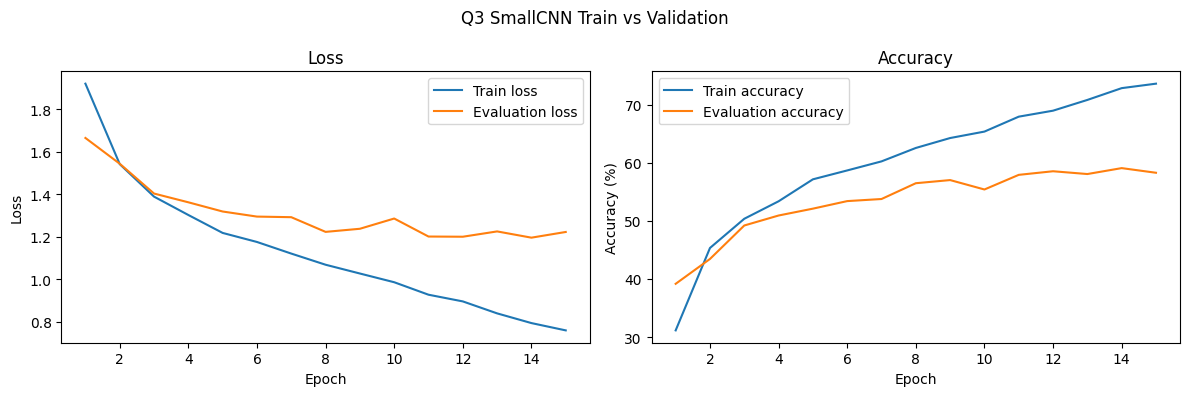

Training LargeCNN
Epoch 01/15 | Train Loss: 2.0214 | Train Acc: 22.51% | Eval Loss: 1.8980 | Eval Acc: 27.94%
Epoch 02/15 | Train Loss: 1.6765 | Train Acc: 36.66% | Eval Loss: 1.6359 | Eval Acc: 38.98%
Epoch 03/15 | Train Loss: 1.4797 | Train Acc: 44.27% | Eval Loss: 1.3869 | Eval Acc: 48.98%
Epoch 04/15 | Train Loss: 1.2908 | Train Acc: 52.44% | Eval Loss: 1.3361 | Eval Acc: 51.16%
Epoch 05/15 | Train Loss: 1.1474 | Train Acc: 58.15% | Eval Loss: 1.2172 | Eval Acc: 56.28%
Epoch 06/15 | Train Loss: 0.9882 | Train Acc: 63.48% | Eval Loss: 1.1308 | Eval Acc: 59.32%
Epoch 07/15 | Train Loss: 0.8435 | Train Acc: 69.61% | Eval Loss: 1.1537 | Eval Acc: 58.92%
Epoch 08/15 | Train Loss: 0.6862 | Train Acc: 75.63% | Eval Loss: 1.1224 | Eval Acc: 62.14%
Epoch 09/15 | Train Loss: 0.5392 | Train Acc: 80.32% | Eval Loss: 1.2270 | Eval Acc: 62.08%
Epoch 10/15 | Train Loss: 0.3938 | Train Acc: 86.22% | Eval Loss: 1.2907 | Eval Acc: 62.48%
Epoch 11/15 | Train Loss: 0.2834 | Train Acc: 90.26% | Eval Lo

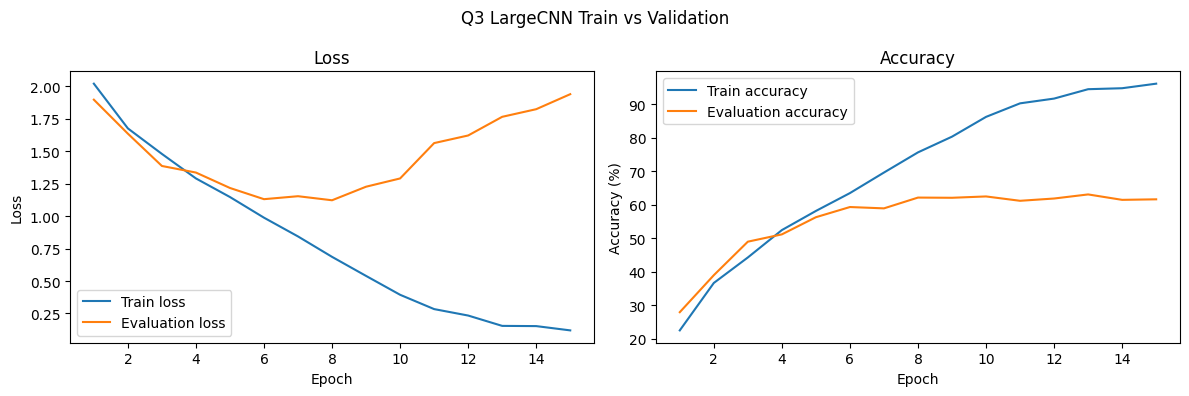

Training LargeCNN with Dropout
Epoch 01/15 | Train Loss: 2.0533 | Train Acc: 21.51% | Eval Loss: 1.7802 | Eval Acc: 31.48%
Epoch 02/15 | Train Loss: 1.7082 | Train Acc: 34.39% | Eval Loss: 1.6497 | Eval Acc: 38.34%
Epoch 03/15 | Train Loss: 1.5048 | Train Acc: 43.95% | Eval Loss: 1.4699 | Eval Acc: 45.66%
Epoch 04/15 | Train Loss: 1.3384 | Train Acc: 50.42% | Eval Loss: 1.3463 | Eval Acc: 50.96%
Epoch 05/15 | Train Loss: 1.1923 | Train Acc: 56.69% | Eval Loss: 1.3767 | Eval Acc: 50.40%
Epoch 06/15 | Train Loss: 1.0778 | Train Acc: 59.88% | Eval Loss: 1.1626 | Eval Acc: 59.12%
Epoch 07/15 | Train Loss: 0.9315 | Train Acc: 66.56% | Eval Loss: 1.2009 | Eval Acc: 58.14%
Epoch 08/15 | Train Loss: 0.8001 | Train Acc: 71.19% | Eval Loss: 1.1198 | Eval Acc: 60.68%
Epoch 09/15 | Train Loss: 0.6506 | Train Acc: 76.71% | Eval Loss: 1.1815 | Eval Acc: 61.20%
Epoch 10/15 | Train Loss: 0.5501 | Train Acc: 80.45% | Eval Loss: 1.2017 | Eval Acc: 63.38%
Epoch 11/15 | Train Loss: 0.4358 | Train Acc: 84.

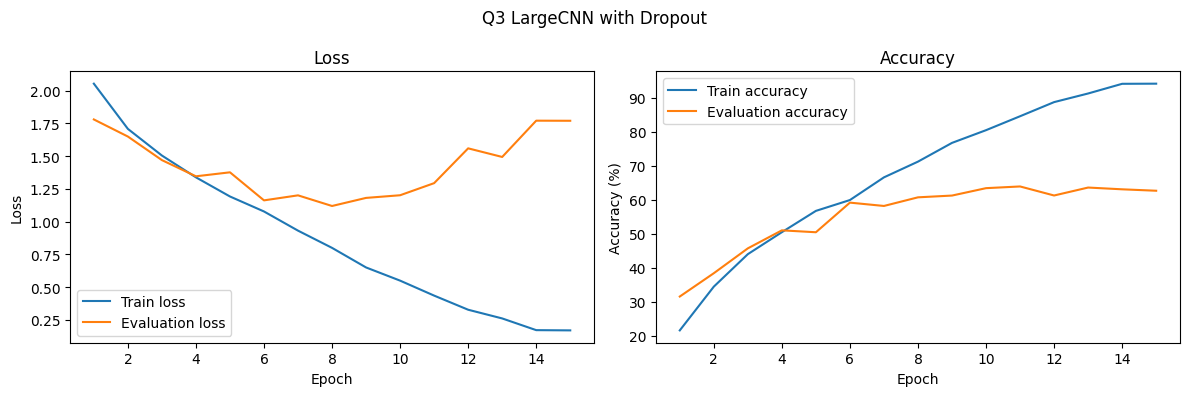

Training LargeCNN with Weight Decay
Epoch 01/15 | Train Loss: 1.9897 | Train Acc: 23.52% | Eval Loss: 1.8304 | Eval Acc: 28.78%
Epoch 02/15 | Train Loss: 1.6656 | Train Acc: 36.53% | Eval Loss: 1.5564 | Eval Acc: 40.48%
Epoch 03/15 | Train Loss: 1.4580 | Train Acc: 45.02% | Eval Loss: 1.4281 | Eval Acc: 45.66%
Epoch 04/15 | Train Loss: 1.3016 | Train Acc: 52.28% | Eval Loss: 1.3367 | Eval Acc: 49.26%
Epoch 05/15 | Train Loss: 1.1800 | Train Acc: 56.54% | Eval Loss: 1.2940 | Eval Acc: 52.58%
Epoch 06/15 | Train Loss: 1.0559 | Train Acc: 61.49% | Eval Loss: 1.2216 | Eval Acc: 55.74%
Epoch 07/15 | Train Loss: 0.9207 | Train Acc: 66.52% | Eval Loss: 1.1809 | Eval Acc: 58.02%
Epoch 08/15 | Train Loss: 0.7790 | Train Acc: 71.84% | Eval Loss: 1.2046 | Eval Acc: 58.54%
Epoch 09/15 | Train Loss: 0.6545 | Train Acc: 76.63% | Eval Loss: 1.2553 | Eval Acc: 60.06%
Epoch 10/15 | Train Loss: 0.5188 | Train Acc: 81.57% | Eval Loss: 1.4296 | Eval Acc: 58.28%
Epoch 11/15 | Train Loss: 0.4028 | Train Acc

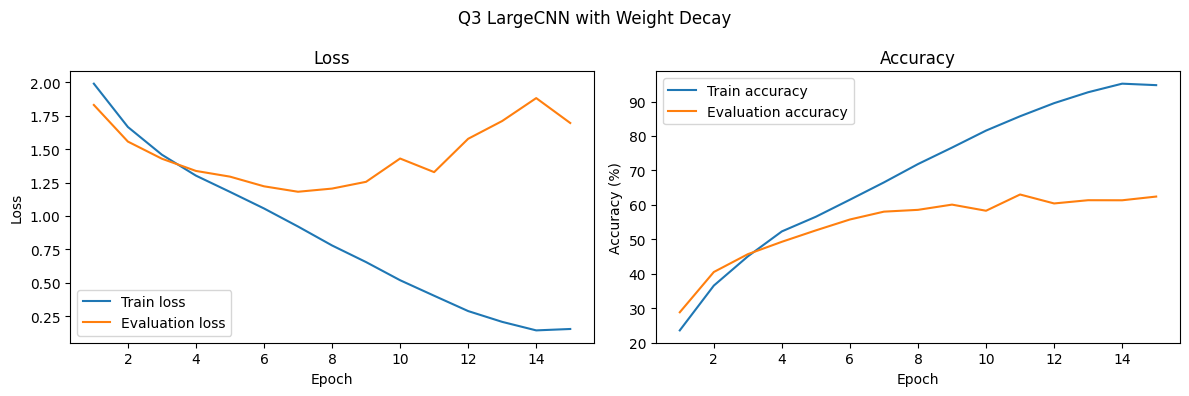

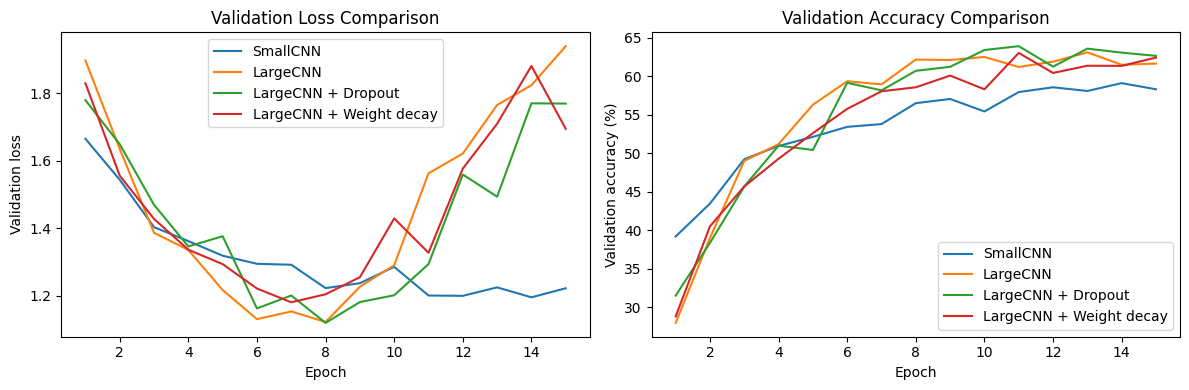


Q3 RESULTS
SmallCNN
Train loss: 0.7583177912084362
Train accuracy: 73.62
Validation loss: 1.2224202364683152
Validation accuracy: 58.28
Parameters: 136874

LargeCNN
Train loss: 0.11928449061852467
Train accuracy: 96.13
Validation loss: 1.940342625975609
Validation accuracy: 61.62
Parameters: 4179082

LargeCNN + Dropout
Train loss: 0.17036310489041895
Train accuracy: 94.14
Validation loss: 1.7700990229845046
Validation accuracy: 62.62

LargeCNN + Weight Decay
Train loss: 0.15394754387155363
Train accuracy: 94.77
Validation loss: 1.6953282713890077
Validation accuracy: 62.4

Good model epoch based on lowest validation loss: 8
Best validation accuracy epoch: 13
Estimated first overfitting epoch for LargeCNN: 7


In [2]:
# QUESTION 3 — overfitting analysis

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

class LargeCNN(nn.Module):
    def __init__(self, use_dropout=False):
        super().__init__()

        self.use_dropout = use_dropout

        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)

        self.fc1 = nn.Linear(512 * 2 * 2, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)

        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))

        if self.use_dropout:
            x = self.dropout(x)

        x = F.relu(self.fc2(x))

        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc3(x)

        return x


q3_train_subset = Subset(
    train_dataset,
    list(range(10000))
)

q3_train_loader = DataLoader(
    q3_train_subset,
    batch_size=batch_size,
    shuffle=True
)

q3_val_loader = val_loader

num_epochs = 15

print("Training SmallCNN")

small_model = SmallCNN().to(device)

small_history = train_model(
    model=small_model,
    train_loader=q3_train_loader,
    eval_loader=q3_val_loader,
    epochs=num_epochs,
    lr=0.001
)

plot_learning_curves(
    small_history,
    "Q3 SmallCNN Train vs Validation"
)

print("Training LargeCNN")

large_model = LargeCNN(use_dropout=False).to(device)

large_history = train_model(
    model=large_model,
    train_loader=q3_train_loader,
    eval_loader=q3_val_loader,
    epochs=num_epochs,
    lr=0.001)

plot_learning_curves(
    large_history,
    "Q3 LargeCNN Train vs Validation")

print("Training LargeCNN with Dropout")

dropout_model = LargeCNN(use_dropout=True).to(device)

dropout_history = train_model(
    model=dropout_model,
    train_loader=q3_train_loader,
    eval_loader=q3_val_loader,
    epochs=num_epochs,
    lr=0.001
)

plot_learning_curves(
    dropout_history,
    "Q3 LargeCNN with Dropout")

print("Training LargeCNN with Weight Decay")

weight_decay_model = LargeCNN(use_dropout=False).to(device)

weight_decay_history = train_model(
    model=weight_decay_model,
    train_loader=q3_train_loader,
    eval_loader=q3_val_loader,
    epochs=num_epochs,
    lr=0.001,
    weight_decay=1e-4)

plot_learning_curves(
    weight_decay_history,
    "Q3 LargeCNN with Weight Decay")

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, small_history["eval_loss"], label="SmallCNN")
plt.plot(epochs_range, large_history["eval_loss"], label="LargeCNN")
plt.plot(epochs_range, dropout_history["eval_loss"], label="LargeCNN + Dropout")
plt.plot(epochs_range, weight_decay_history["eval_loss"], label="LargeCNN + Weight decay")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, small_history["eval_acc"], label="SmallCNN")
plt.plot(epochs_range, large_history["eval_acc"], label="LargeCNN")
plt.plot(epochs_range, dropout_history["eval_acc"], label="LargeCNN + Dropout")
plt.plot(epochs_range, weight_decay_history["eval_acc"], label="LargeCNN + Weight decay")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.tight_layout()
plt.show()

overfit_epoch = None

for i in range(1, num_epochs):
    train_loss_decreased = large_history["train_loss"][i] < large_history["train_loss"][i - 1]
    val_loss_increased = large_history["eval_loss"][i] > large_history["eval_loss"][i - 1]

    if train_loss_decreased and val_loss_increased:
        overfit_epoch = i + 1
        break

best_val_loss_epoch = int(np.argmin(large_history["eval_loss"])) + 1
best_val_acc_epoch = int(np.argmax(large_history["eval_acc"])) + 1

print("\nQ3 RESULTS")
print("=" * 50)

print("SmallCNN")
print("Train loss:", small_history["train_loss"][-1])
print("Train accuracy:", small_history["train_acc"][-1])
print("Validation loss:", small_history["eval_loss"][-1])
print("Validation accuracy:", small_history["eval_acc"][-1])
print("Parameters:", count_parameters(small_model))

print("\nLargeCNN")
print("Train loss:", large_history["train_loss"][-1])
print("Train accuracy:", large_history["train_acc"][-1])
print("Validation loss:", large_history["eval_loss"][-1])
print("Validation accuracy:", large_history["eval_acc"][-1])
print("Parameters:", count_parameters(large_model))

print("\nLargeCNN + Dropout")
print("Train loss:", dropout_history["train_loss"][-1])
print("Train accuracy:", dropout_history["train_acc"][-1])
print("Validation loss:", dropout_history["eval_loss"][-1])
print("Validation accuracy:", dropout_history["eval_acc"][-1])

print("\nLargeCNN + Weight Decay")
print("Train loss:", weight_decay_history["train_loss"][-1])
print("Train accuracy:", weight_decay_history["train_acc"][-1])
print("Validation loss:", weight_decay_history["eval_loss"][-1])
print("Validation accuracy:", weight_decay_history["eval_acc"][-1])

print("\nGood model epoch based on lowest validation loss:", best_val_loss_epoch)
print("Best validation accuracy epoch:", best_val_acc_epoch)
print("Estimated first overfitting epoch for LargeCNN:", overfit_epoch)